# Lorenz-63 gradient-guided data assimilation baseline

This notebook trains an unconditional flow-matching MLP on Lorenz-63 states and then performs assimilation with gradient guidance from sparse point observations.

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lorenz_baseline").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from lorenz_baseline.common import (
    DEFAULT_GUIDANCE_SCALE,
    DEFAULT_LR,
    DEFAULT_NUM_EPOCHS,
    DEFAULT_POSTERIOR_NOISE_STD,
    DEFAULT_NUM_STEPS,
    DEFAULT_SEED,
    FlowMatchingMLP,
    Standardizer,
    choose_training_device,
    describe_runtime,
    evaluate_gradient_assimilation,
    evaluate_mean_fill_baseline,
    evaluate_posterior_restoration,
    fit_flow_matching,
    load_split_states,
    make_fixed_conditioning,
    make_state_loader,
    plot_attractor_comparison,
    plot_loss_curves,
    plot_posterior_case,
    plot_reconstruction_examples,
    set_seed,
)


In [2]:
set_seed(DEFAULT_SEED)

DATA_DIR = REPO_ROOT / "lorenz_baseline" / "data"
if not DATA_DIR.exists():
    raise FileNotFoundError("Run `python -m lorenz_baseline.generate_dataset` before training.")

device = choose_training_device(prefer_mps=True)
runtime = describe_runtime(device)
print(runtime)

splits = {name: load_split_states(DATA_DIR, name) for name in ("train", "val", "test")}
standardizer = Standardizer.from_states(splits["train"])

batch_size = runtime["batch_size"]
num_workers = runtime["num_workers"]

train_loader = make_state_loader(
    splits["train"], batch_size=batch_size, shuffle=True, num_workers=num_workers, device_type=device.type
)
val_loader = make_state_loader(
    splits["val"], batch_size=batch_size, shuffle=False, num_workers=num_workers, device_type=device.type
)

test_mask, _ = make_fixed_conditioning(splits["test"], seed=DEFAULT_SEED + 1)
print({k: v.shape for k, v in splits.items()})


{'device': 'mps', 'batch_size': 4096, 'num_workers': 4, 'pin_memory': False, 'persistent_workers': True}
{'train': (200000, 3), 'val': (20000, 3), 'test': (20000, 3)}


In [3]:
model = FlowMatchingMLP(
    state_dim=3,
    conditional=False,
    hidden_dim=256,
    hidden_layers=4,
    time_embed_dim=64,
).to(device)

history = fit_flow_matching(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    standardizer=standardizer,
    device=device,
    conditional=False,
    epochs=DEFAULT_NUM_EPOCHS,
    lr=DEFAULT_LR,
)


train epoch 1/60:   0%|          | 0/49 [00:00<?, ?it/s]

val epoch 1/60:   0%|          | 0/5 [00:00<?, ?it/s]

epoch 001 | train_loss=1.734515 | val_loss=1.560219


train epoch 2/60:   0%|          | 0/49 [00:00<?, ?it/s]

val epoch 2/60:   0%|          | 0/5 [00:00<?, ?it/s]

...

val epoch 59/60:   0%|          | 0/5 [00:00<?, ?it/s]

epoch 059 | train_loss=1.282439 | val_loss=1.278814


train epoch 60/60:   0%|          | 0/49 [00:00<?, ?it/s]

val epoch 60/60:   0%|          | 0/5 [00:00<?, ?it/s]

epoch 060 | train_loss=1.282643 | val_loss=1.260758


In [4]:
baseline_results = evaluate_mean_fill_baseline(splits["test"], test_mask, standardizer)
gradient_results = evaluate_gradient_assimilation(
    model=model,
    states=splits["test"],
    mask=test_mask,
    standardizer=standardizer,
    device=device,
    batch_size=batch_size,
    num_steps=DEFAULT_NUM_STEPS,
    guidance_scale=DEFAULT_GUIDANCE_SCALE,
    seed=DEFAULT_SEED + 2,
)

print("baseline:", baseline_results["metrics"])
print("gradient:", gradient_results["metrics"])


gradient assimilation:   0%|          | 0/5 [00:00<?, ?it/s]

gradient assimilation steps 0:4096:   0%|          | 0/128 [00:00<?, ?it/s]

gradient assimilation steps 4096:8192:   0%|          | 0/128 [00:00<?, ?it/s]

gradient assimilation steps 8192:12288:   0%|          | 0/128 [00:00<?, ?it/s]

gradient assimilation steps 12288:16384:   0%|          | 0/128 [00:00<?, ?it/s]

gradient assimilation steps 16384:20000:   0%|          | 0/128 [00:00<?, ?it/s]

baseline: {'rmse': 5.9263176918029785, 'observed_rmse': 0.0, 'unobserved_rmse': 8.387371777937673}
gradient: {'rmse': 11.899606704711914, 'observed_rmse': 11.912453155824599, 'unobserved_rmse': 11.886707873479413}


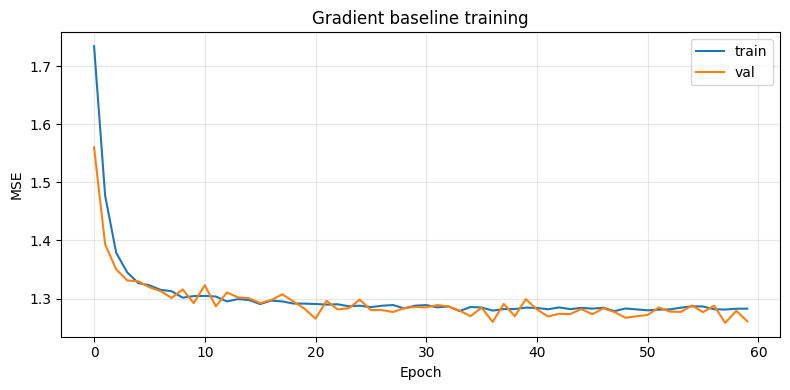

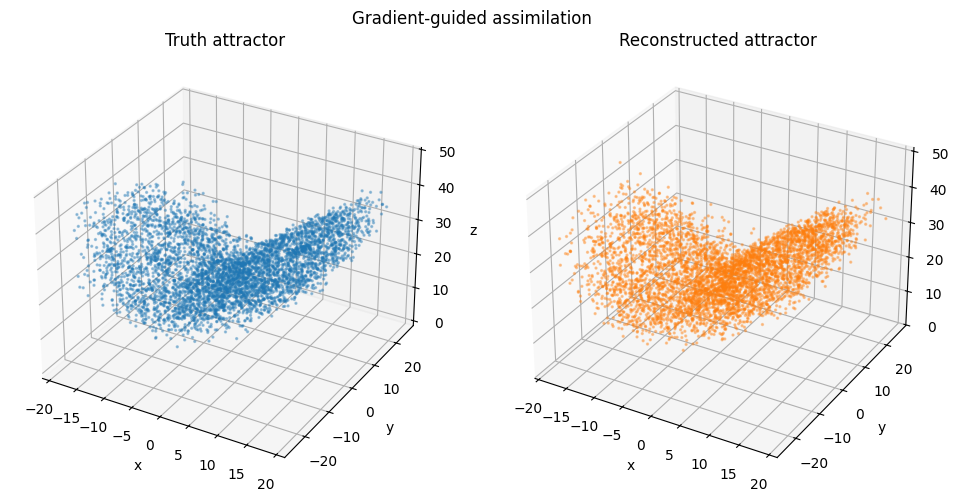

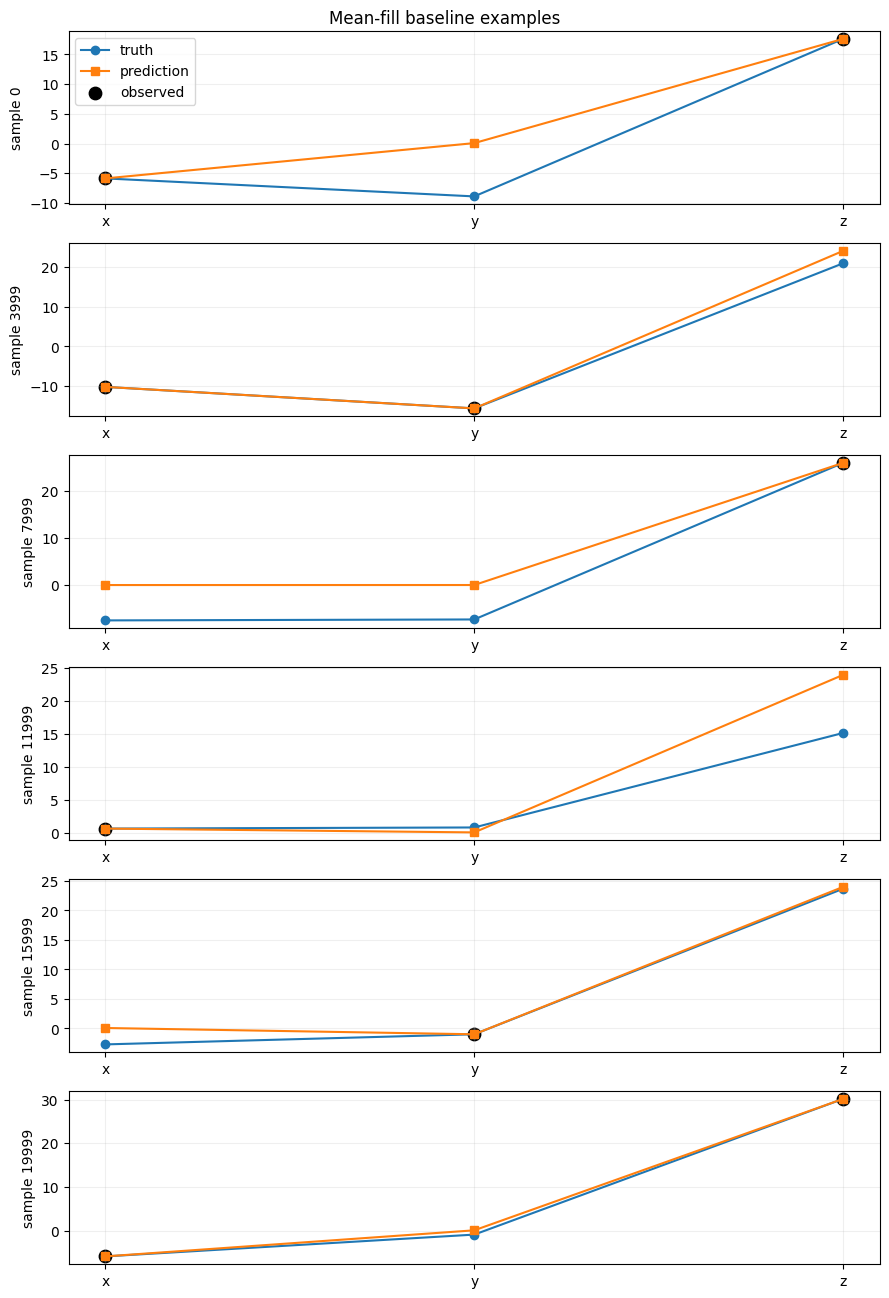

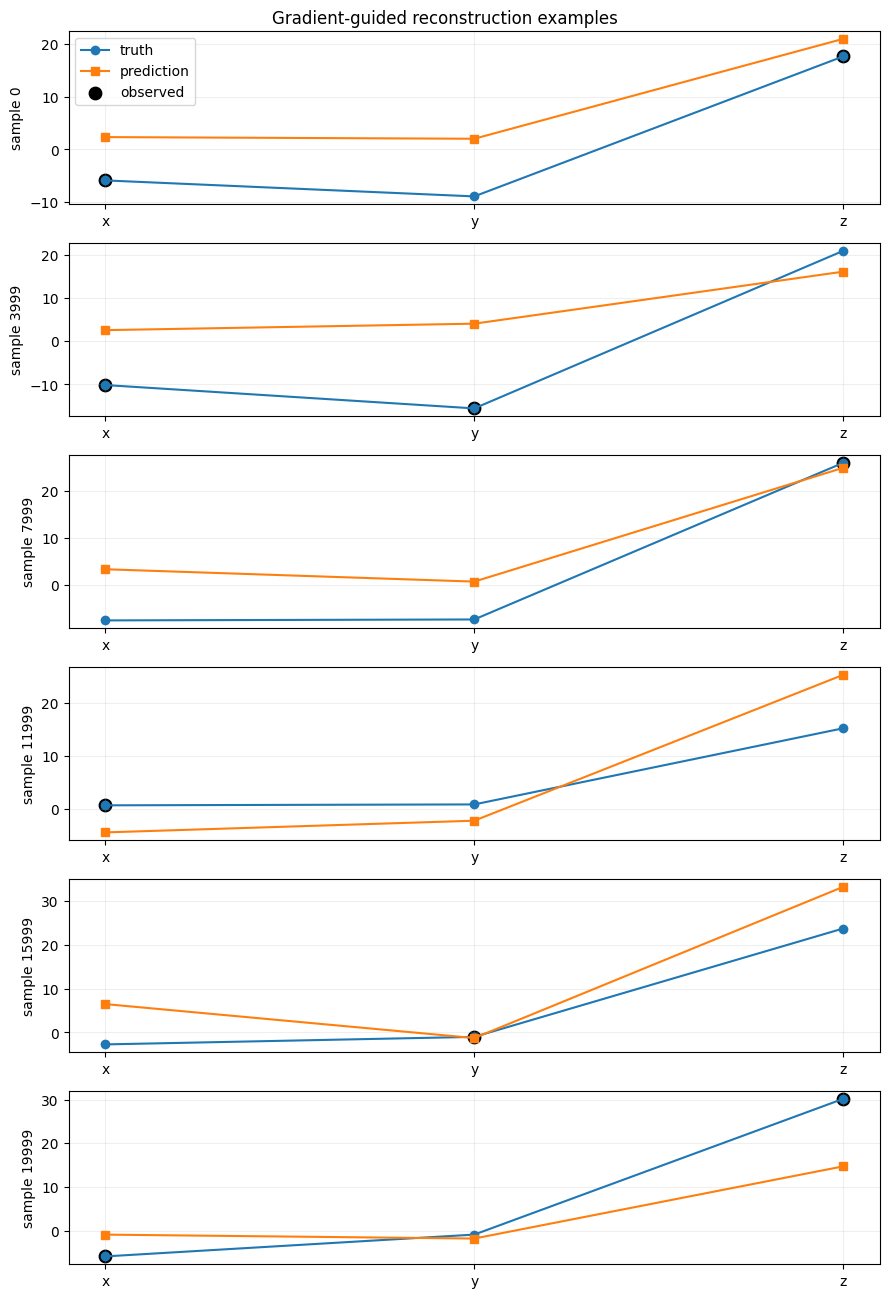

In [5]:
plot_loss_curves(history, title="Gradient baseline training")
plot_attractor_comparison(splits["test"], gradient_results["predictions"], title="Gradient-guided assimilation")
plot_reconstruction_examples(
    splits["test"], baseline_results["predictions"], test_mask, title="Mean-fill baseline examples"
)
plot_reconstruction_examples(
    splits["test"], gradient_results["predictions"], test_mask, title="Gradient-guided reconstruction examples"
)


In [6]:
posterior_results = evaluate_posterior_restoration(
    model=model,
    train_states=splits["train"],
    test_states=splits["test"],
    standardizer=standardizer,
    device=device,
    conditional=False,
    obs_noise_std=DEFAULT_POSTERIOR_NOISE_STD,
    num_cases=16,
    num_posterior_samples=256,
    num_steps=DEFAULT_NUM_STEPS,
    guidance_scale=DEFAULT_GUIDANCE_SCALE,
    reference_bank_size=50000,
    seed=DEFAULT_SEED + 100,
)
print(posterior_results["summary"])


posterior restoration:   0%|          | 0/16 [00:00<?, ?it/s]

posterior case 1/16:   0%|          | 0/128 [00:00<?, ?it/s]

posterior case 2/16:   0%|          | 0/128 [00:00<?, ?it/s]

posterior case 3/16:   0%|          | 0/128 [00:00<?, ?it/s]

posterior case 4/16:   0%|          | 0/128 [00:00<?, ?it/s]

...

posterior case 13/16:   0%|          | 0/128 [00:00<?, ?it/s]

posterior case 14/16:   0%|          | 0/128 [00:00<?, ?it/s]

posterior case 15/16:   0%|          | 0/128 [00:00<?, ?it/s]

posterior case 16/16:   0%|          | 0/128 [00:00<?, ?it/s]

{'reference_expected_log_prior': -3.727404409795845, 'reference_expected_log_likelihood': 0.6762737490649969, 'approx_expected_log_prior': -3.482015965182079, 'approx_expected_log_likelihood': -70.86848057538654, 'wasserstein': 15.018131999699566}


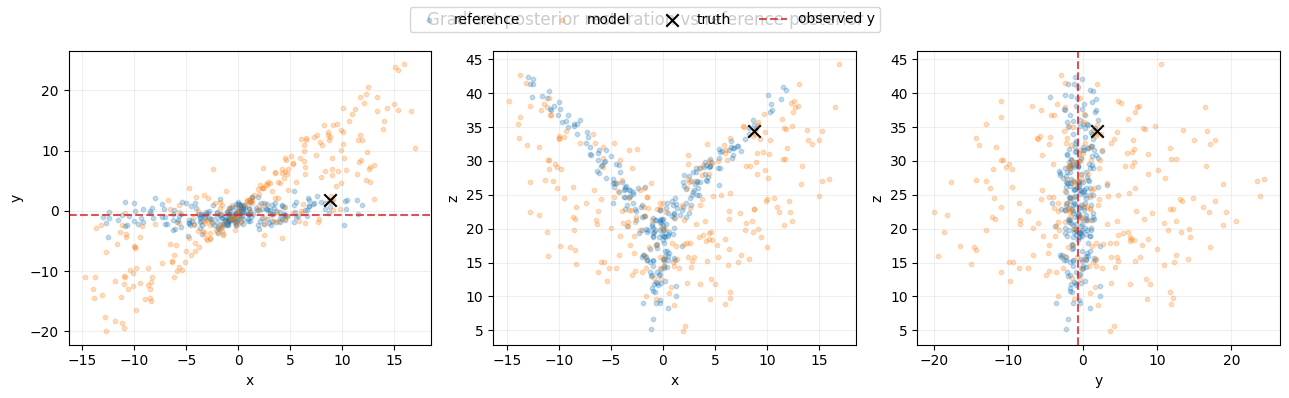

In [7]:
case0 = posterior_results["details"][0]
plot_posterior_case(
    reference_samples=case0["reference_samples_raw"],
    approx_samples=case0["approx_samples_raw"],
    truth_state=case0["truth_raw"],
    mask=case0["mask"],
    obs_raw=case0["obs_raw"],
    title="Gradient posterior restoration vs reference posterior",
)
